In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/content/Social_Network_Ads.csv')
df = df.iloc[:, 2:]


In [12]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [ ]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)


In [ ]:
# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [13]:
# Model
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x


In [14]:
model = Model()

In [15]:
# Loss & Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:

# Training
epochs = 100
val_acc_list = []

for epoch in range(epochs):
    # Forward
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    with torch.no_grad():
        val_outputs = model(X_test)
        preds = (val_outputs > 0.5).float()
        acc = (preds == y_test).float().mean()
        val_acc_list.append(acc.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Val Acc: {acc.item():.4f}")

Epoch 0, Loss: 65.3125, Val Acc: 0.4000
Epoch 10, Loss: 65.3125, Val Acc: 0.4000
Epoch 20, Loss: 65.3125, Val Acc: 0.4000
Epoch 30, Loss: 65.3125, Val Acc: 0.4000
Epoch 40, Loss: 65.3125, Val Acc: 0.4000
Epoch 50, Loss: 65.3125, Val Acc: 0.4000
Epoch 60, Loss: 65.3125, Val Acc: 0.4000
Epoch 70, Loss: 65.3125, Val Acc: 0.4000
Epoch 80, Loss: 65.3125, Val Acc: 0.4000
Epoch 90, Loss: 65.3125, Val Acc: 0.4000


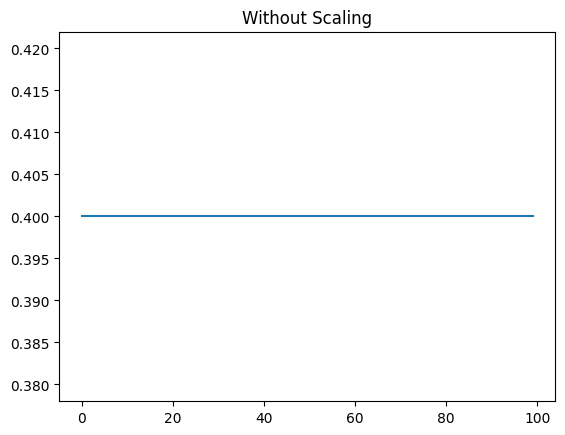

In [17]:
# Plot
plt.plot(val_acc_list)
plt.title("Without Scaling")
plt.show()

🔍 What your graph means

Validation accuracy ≈ 0.60 for all epochs

No improvement at all

Model is basically not learning anything

👉 This is exactly what we expect without scaling

Epoch 0, Loss: 0.7681, Val Acc: 0.4000
Epoch 10, Loss: 0.6657, Val Acc: 0.6500
Epoch 20, Loss: 0.5855, Val Acc: 0.8250
Epoch 30, Loss: 0.5239, Val Acc: 0.8125
Epoch 40, Loss: 0.4766, Val Acc: 0.8250
Epoch 50, Loss: 0.4395, Val Acc: 0.8250
Epoch 60, Loss: 0.4100, Val Acc: 0.8250
Epoch 70, Loss: 0.3859, Val Acc: 0.8250
Epoch 80, Loss: 0.3658, Val Acc: 0.8375
Epoch 90, Loss: 0.3490, Val Acc: 0.8375


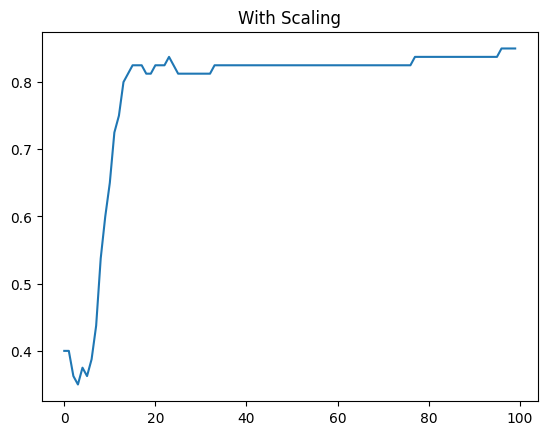

In [18]:
from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.numpy())
X_test_scaled = scaler.transform(X_test.numpy())

# Convert back to tensor
X_train_scaled = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)

# New model
model = Model()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
val_acc_list_scaled = []

for epoch in range(epochs):
    # Forward
    outputs = model(X_train_scaled)
    loss = criterion(outputs, y_train)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    with torch.no_grad():
        val_outputs = model(X_test_scaled)
        preds = (val_outputs > 0.5).float()
        acc = (preds == y_test).float().mean()
        val_acc_list_scaled.append(acc.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Val Acc: {acc.item():.4f}")

# Plot
plt.plot(val_acc_list_scaled)
plt.title("With Scaling")
plt.show()

🔍 What this second graph shows

Accuracy jumps quickly → ~0.88 early

Then stabilizes around 0.83–0.85

Small fluctuations (normal)

👉 Most important:

The model is actually learning now